In [1]:
import pandas as pd
import numpy as np
import math
import random
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

MODELS_CACHE = {}

def main(year, sim_count):
    
    data = pd.read_csv("../../data/data_official.csv")
    
    if year not in MODELS_CACHE:
        try:
            with open(f'../RFmodels/rf_model_{year}.pkl', 'rb') as f:
                MODELS_CACHE[year] = pickle.load(f)
        except FileNotFoundError:
            raise ValueError(f"Model for year {year} not found. Please train it first.")
            
    model = MODELS_CACHE[year]
    
    data['Sim_Wins'] = [-1 for _ in range(len(data))]
    data['R68_win%'] = [1.0 for _ in range(len(data))]
    data['R64_win%'] = [0.0 for _ in range(len(data))]
    data['R32_win%'] = [0.0 for _ in range(len(data))]
    data['S16_win%'] = [0.0 for _ in range(len(data))]
    data['E8_win%'] = [0.0 for _ in range(len(data))]
    data['F4_win%'] = [0.0 for _ in range(len(data))]
    data['CG_win%'] = [0.0 for _ in range(len(data))]
    data['R68_opp'] = ["N/A" for _ in range(len(data))]
    data['R64_opp'] = ["N/A" for _ in range(len(data))]
    data['R32_opp'] = ["N/A" for _ in range(len(data))]
    data['S16_opp'] = ["N/A" for _ in range(len(data))]
    data['E8_opp'] = ["N/A" for _ in range(len(data))]
    data['F4_opp'] = ["N/A" for _ in range(len(data))]
    data['CG_opp'] = ["N/A" for _ in range(len(data))]
    
    i = 0
    
    sims = []
    scores = []
        
    while i < sim_count:
        
        sim_df = simulation(year, i, data, model)
        
        score = 0

        score = score + (10 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 0) & (sim_df["Sim_Wins"] > 0)])))
        score = score + (20 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 1) & (sim_df["Sim_Wins"] > 1)])))
        score = score + (40 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 2) & (sim_df["Sim_Wins"] > 2)])))
        score = score + (80 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 3) & (sim_df["Sim_Wins"] > 3)])))
        score = score + (160 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 4) & (sim_df["Sim_Wins"] > 4)])))
        score = score + (320 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 5) & (sim_df["Sim_Wins"] > 5)])))
        
        sims.append(sim_df)
        scores.append(score)
        i = i+1
                
    full_df = pd.concat(sims, axis=0).reset_index(drop=True)
    
    final_df = calc_outcome(full_df)
    
    final_df1 = final_df[['sim_num', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp', 'Outcome_%']]
        
    return final_df1, scores

def simulation(year, sim_num, data, model):
    
    data = data.copy()
    
    data['sim_num'] = sim_num + 1
    
    df1 = region_simulation(data, year, 1, model)
    df1n = df1[df1["QUAD ID"] == 1]
    df2 = region_simulation(data, year, 2, model)
    df2n = df2[df2["QUAD ID"] == 2]
    df3 = region_simulation(data, year, 3, model)
    df3n = df3[df3["QUAD ID"] == 3]
    df4 = region_simulation(data, year, 4, model)
    df4n = df4[df4["QUAD ID"] == 4]
    
    df = pd.concat([df1n, df2n, df3n, df4n])
        
    df = final4(df, year, model)
    
    df = championship(df, year, model)
    
    df_year = df[df["YEAR"] == year]
    dfn = df_year[['sim_num', 'YEAR', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp']]
                            
    return dfn

def region_simulation(data, year, quad, model):
    
    seeds = list(range(1,17))

    ###########################################################################
    # FIRST FOUR
    
    for seed in seeds:
    
        if data[(data["SEED"] == seed) & (data["YEAR"] == year) & (data["QUAD ID"] == quad)].shape[0] > 1:
            
            data = same_seed(data, year, quad, seed, model)
    ##########################################################################
    ##########################################################################
    # FIRST ROUND (R64)
        
    data = round64(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SECOND ROUND (R32)
    
    data = round32(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SWEET 16
    
    data = sweet16(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # ELITE 8
    
    data = elite8(data, year, quad, model)
    
    return data

def same_seed(data, year, quad, seed, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["SEED"] == seed)].copy()
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    
    data.loc[team0index, "R68_win%"] = perc
    data.loc[team1index, "R68_win%"] = 1-perc
    data.loc[team0index, "R68_opp"] = team1name
    data.loc[team1index, "R68_opp"] = team0name
    
    winner = weighted_coin_flip(perc)

    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 0

    else:
        data.loc[team0index, "Sim_Wins"] = 0
        
    return data

def round64(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    seeds1 = [1,2,3,4,5,6,7,8]
    seeds2 = [16,15,14,13,12,11,10,9]
    
    for i in range(0,8):
        
        rdf = subdf[(subdf["SEED"] == seeds1[i]) | (subdf["SEED"] == seeds2[i])]
        team0 = rdf.head(1)
        team0name = str(team0["TEAM"].iloc[0])
        team0index = team0["TEAM"].index
        team1 = rdf.tail(1)
        team1name = str(team1["TEAM"].iloc[0])
        team1index = team1["TEAM"].index
                
        perc = find_percentages(data, team0name, team1name, year, model)
        
        data.loc[team0index, "R64_win%"] = perc
        data.loc[team1index, "R64_win%"] = 1-perc
        data.loc[team0index, "R64_opp"] = team1name
        data.loc[team1index, "R64_opp"] = team0name

        winner = weighted_coin_flip(perc)
        
        if winner == 1:
            data.loc[team1index, "Sim_Wins"] = 0

        else:
            data.loc[team0index, "Sim_Wins"] = 0

    return data

def round32(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[(subdf["SEED"] == 1) | (subdf["SEED"] == 16)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 8) | (subdf["SEED"] == 9)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 5) | (subdf["SEED"] == 12)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 4) | (subdf["SEED"] == 13)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 6) | (subdf["SEED"] == 11)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 3) | (subdf["SEED"] == 14)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 7) | (subdf["SEED"] == 10)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 2) | (subdf["SEED"] == 15)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
        
    return data

def sweet16(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,8,9,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options2 = [4,5,12,13]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2

    options3 = [3,6,11,14]
    for i in options3:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options4 = [2,7,10,15]
    for i in options4:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2  
    
    return data

def elite8(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,4,5,8,9,12,13,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    
    options2 = [2,3,6,7,10,11,14,15]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "E8_win%"] = perc
    data.loc[team1index, "E8_win%"] = 1-perc
    data.loc[team0index, "E8_opp"] = team1name
    data.loc[team1index, "E8_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 3
    else:
        data.loc[team0index, "Sim_Wins"] = 3
        
    return data

def final4(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[subdf["QUAD ID"] == 1]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 2]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4
        
    team0 = subdf[subdf["QUAD ID"] == 3]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 4]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
        
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4    
    
    return data

def championship(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "CG_win%"] = perc
    data.loc[team1index, "CG_win%"] = 1-perc
    data.loc[team0index, "CG_opp"] = team1name
    data.loc[team1index, "CG_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 5
        data.loc[team0index, "Sim_Wins"] = 6
    else:
        data.loc[team0index, "Sim_Wins"] = 5
        data.loc[team1index, "Sim_Wins"] = 6    
    
    return data

def game_style(df, team0, team1, year):
    
    cols = ['KADJ T',
       'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 'TOV%',
       'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', '3PT%D', 'AST%',
       '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 'EXP', 'FT%',
       'ELITE SOS']
    
    t0 = df[(df["TEAM"] == team0) & (df["YEAR"] == year)].reset_index(drop=True)
    t1 = df[(df["TEAM"] == team1) & (df["YEAR"] == year)].reset_index(drop=True)
    
    game = pd.DataFrame()
    
    for col in cols:
        game[col] = t0[col] - t1[col]
    game.insert(0, "YEAR", year)
    game.insert(1, "Team0", t0["TEAM"])
    game.insert(2, "Team1", t1["TEAM"])
    
    return game

def find_percentages(df, team0, team1, year, model):
    
    features = ['KADJ T', 'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 
                'TOV%', 'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', 
                '3PT%D', 'AST%', '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 
                'EXP', 'FT%', 'ELITE SOS']
    
    game_01 = game_style(df, team0, team1, year)
    game_10 = game_style(df, team1, team0, year)
    
    X_test_01 = game_01[features].values
    X_test_10 = game_10[features].values
    
    probs_01 = model.predict_proba(X_test_01)[0]
    probs_10 = model.predict_proba(X_test_10)[0]
    
    team0_win_prob = (probs_01[0] + probs_10[1]) / 2
    team1_win_prob = (probs_01[1] + probs_10[0]) / 2
    
    return team0_win_prob

def weighted_coin_flip(perc1):
    
    num = random.random()
    
    if num < perc1:
        return 1
    
    else:
        return 2
    
def calc_outcome(df):
    
    df['Outcome_%'] = [0 for _ in range(len(df))]
    
    df.loc[df['Sim_Wins'] == 6, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * df['CG_win%']
    df.loc[df['Sim_Wins'] == 5, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * (1-df['CG_win%'])
    df.loc[df['Sim_Wins'] == 4, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * (1-df['F4_win%'])
    df.loc[df['Sim_Wins'] == 3, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * (1-df['E8_win%'])
    df.loc[df['Sim_Wins'] == 2, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * (1-df['S16_win%'])
    df.loc[df['Sim_Wins'] == 1, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * (1-df['R32_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] != 0), 'Outcome_%'] = df['R68_win%'] * (1-df['R64_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] == 0), 'Outcome_%'] = (1-df['R68_win%'])
    
    df['R68_win%'] = df['R68_win%'].mul(100).round(3)
    df['R64_win%'] = df['R64_win%'].mul(100).round(3)
    df['R32_win%'] = df['R32_win%'].mul(100).round(3)
    df['S16_win%'] = df['S16_win%'].mul(100).round(3)
    df['E8_win%'] = df['E8_win%'].mul(100).round(3)
    df['F4_win%'] = df['F4_win%'].mul(100).round(3)
    df['CG_win%'] = df['CG_win%'].mul(100).round(3)
    df['Outcome_%'] = df['Outcome_%'].mul(100).round(3)
        
    return df

In [2]:
df, scores = main(2025, 10000)

In [3]:
import numpy as np

top_5_indices = np.argsort(scores)[-5:][::-1]  
top_5 = [(i+1, scores[i]) for i in top_5_indices] 

bottom_5_indices = np.argsort(scores)[:5]  
bottom_5 = [(i+1, scores[i]) for i in bottom_5_indices]

avg_score = np.mean(scores)

print("=" * 40)
print("TOP 5 SCORES")
print("=" * 40)
for sim_num, score in top_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print("BOTTOM 5 SCORES")
print("=" * 40)
for sim_num, score in bottom_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print(f"AVERAGE SCORE: {avg_score:.2f}")
print("=" * 40)

TOP 5 SCORES
Sim #398: 1710
Sim #3254: 1710
Sim #6820: 1700
Sim #3833: 1700
Sim #2098: 1690

BOTTOM 5 SCORES
Sim #5081: 240
Sim #5521: 260
Sim #1450: 270
Sim #6249: 280
Sim #4788: 280

AVERAGE SCORE: 846.21


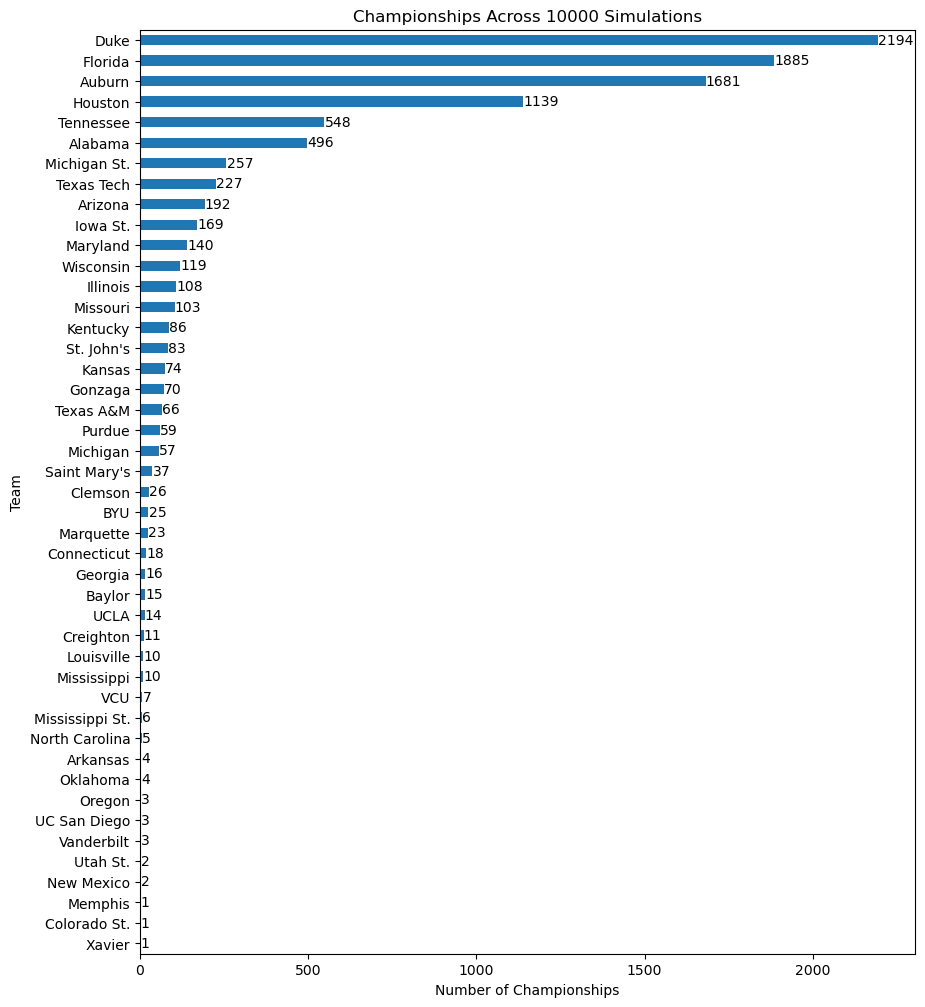

In [5]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] == 6, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Championships Across 10000 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Championships")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [6]:
from itertools import zip_longest
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] == 6)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Championships by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Championships by Team for 10000 Simulations

Duke              2194 --> 21.94%          BYU                25 --> 0.25%            Drake               0 --> 0.0%          
Florida           1885 --> 18.85%          Marquette          23 --> 0.23%            San Diego St.       0 --> 0.0%          
Auburn            1681 --> 16.81%          Connecticut        18 --> 0.18%            McNeese St.         0 --> 0.0%          
Houston           1139 --> 11.39%          Georgia            16 --> 0.16%            Liberty             0 --> 0.0%          
Tennessee         548 --> 5.48%            Baylor             15 --> 0.15%            High Point          0 --> 0.0%          
Alabama           496 --> 4.96%            UCLA               14 --> 0.14%            Akron               0 --> 0.0%          
Michigan St.      257 --> 2.57%            Creighton          11 --> 0.11%            Grand Canyon        0 --> 0.0%          
Texas Tech        227 --> 2.27%            Mississippi        10 -

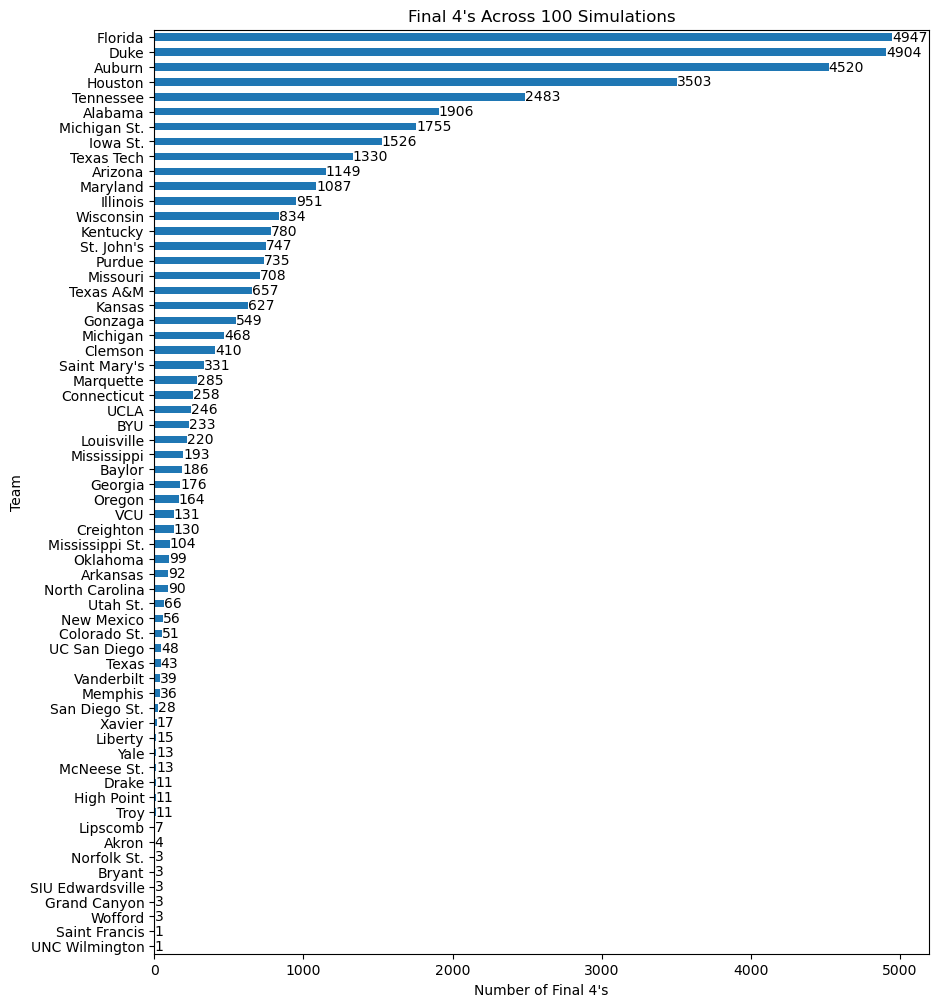

In [7]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] >= 4, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Final 4's Across 100 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Final 4's")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [8]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 4)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Final 4's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Final 4's by Team for 10000 Simulations

Florida           4947 --> 49.47%          Marquette         285 --> 2.85%            Xavier             17 --> 0.17%         
Duke              4904 --> 49.04%          Connecticut       258 --> 2.58%            Liberty            15 --> 0.15%         
Auburn            4520 --> 45.2%           UCLA              246 --> 2.46%            McNeese St.        13 --> 0.13%         
Houston           3503 --> 35.03%          BYU               233 --> 2.33%            Yale               13 --> 0.13%         
Tennessee         2483 --> 24.83%          Louisville        220 --> 2.2%             Drake              11 --> 0.11%         
Alabama           1906 --> 19.06%          Mississippi       193 --> 1.93%            High Point         11 --> 0.11%         
Michigan St.      1755 --> 17.55%          Baylor            186 --> 1.86%            Troy               11 --> 0.11%         
Iowa St.          1526 --> 15.26%          Georgia           176 --> 1

In [9]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 3)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Elite 8's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Elite 8's by Team for 10000 Simulations

Duke              6362 --> 63.62%          Marquette         939 --> 9.39%            Liberty            89 --> 0.89%         
Florida           6319 --> 63.19%          BYU               848 --> 8.48%            McNeese St.        87 --> 0.87%         
Auburn            5993 --> 59.93%          UCLA              791 --> 7.91%            High Point         76 --> 0.76%         
Houston           5200 --> 52.0%           Mississippi       680 --> 6.8%             Drake              75 --> 0.75%         
Tennessee         4546 --> 45.46%          Connecticut       627 --> 6.27%            Troy               72 --> 0.72%         
Alabama           4366 --> 43.66%          Louisville        610 --> 6.1%             Yale               70 --> 0.7%          
Michigan St.      4034 --> 40.34%          VCU               603 --> 6.03%            Xavier             57 --> 0.57%         
Iowa St.          3585 --> 35.85%          Georgia           528 --> 5

In [10]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 2)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Sweet 16's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Sweet 16's by Team for 10000 Simulations

Duke              7939 --> 79.39%          BYU               2324 --> 23.24%          McNeese St.       563 --> 5.63%         
Florida           7861 --> 78.61%          Marquette         2315 --> 23.15%          Yale              494 --> 4.94%         
Auburn            7662 --> 76.62%          Gonzaga           2056 --> 20.56%          High Point        484 --> 4.84%         
Maryland          7286 --> 72.86%          Mississippi       1844 --> 18.44%          Drake             461 --> 4.61%         
Tennessee         6964 --> 69.64%          UCLA              1823 --> 18.23%          San Diego St.     443 --> 4.43%         
Houston           6799 --> 67.99%          VCU               1728 --> 17.28%          Troy              399 --> 3.99%         
Michigan St.      6665 --> 66.65%          Louisville        1346 --> 13.46%          Akron             312 --> 3.12%         
Arizona           6646 --> 66.46%          Colorado St.      1245 -->

In [11]:
pd.set_option('display.max_columns', None)
df.sort_values("Outcome_%", ascending=True).head(25)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
476335,7005,4,Saint Francis,16,0,5,36.673,Alabama St.,9.863,Auburn,10.283,Creighton,17.497,UC San Diego,9.408,Iowa St.,8.398,Florida,7.498,Duke,0.000
258001,3795,1,SIU Edwardsville,16,0,5,100.000,N/A,9.555,Houston,11.372,Gonzaga,14.212,Purdue,9.586,Tennessee,10.464,Arizona,11.765,Iowa St.,0.001
111197,1636,2,Akron,13,0,5,100.000,N/A,11.650,Arizona,20.471,Oregon,8.996,Duke,12.682,BYU,16.090,Clemson,9.349,Florida,0.004
62119,914,3,Colorado St.,12,1,6,100.000,N/A,51.884,Memphis,17.344,Maryland,10.252,Florida,22.194,Kansas,32.274,Creighton,13.757,Tennessee,0.009
459961,6765,1,SIU Edwardsville,16,0,4,100.000,N/A,9.555,Houston,11.372,Gonzaga,10.670,Clemson,9.586,Tennessee,11.082,Alabama,0.000,N/A,0.010
176573,2597,3,Norfolk St.,16,0,4,100.000,N/A,7.724,Florida,15.553,Oklahoma,9.772,Maryland,10.766,Texas Tech,12.186,Marquette,0.000,N/A,0.011
76308,1123,1,Troy,14,0,5,100.000,N/A,22.406,Kentucky,15.260,Illinois,12.308,Tennessee,13.297,Houston,23.090,BYU,17.840,Louisville,0.011
49617,730,3,Norfolk St.,16,0,4,100.000,N/A,7.724,Florida,15.553,Oklahoma,9.772,Maryland,10.766,Texas Tech,9.219,Auburn,0.000,N/A,0.011
28251,416,2,Vanderbilt,10,0,6,100.000,N/A,35.410,Saint Mary's,14.193,Alabama,33.362,BYU,13.119,Duke,22.034,Gonzaga,24.767,Michigan St.,0.012
179529,2641,1,SIU Edwardsville,16,0,4,100.000,N/A,9.555,Houston,10.177,Georgia,14.212,Purdue,9.586,Tennessee,7.755,Duke,0.000,N/A,0.012


In [14]:
df[df["sim_num"] == 398].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
27034,398,3,Florida,1,6,6,100.000,N/A,92.276,Norfolk St.,84.346,Connecticut,76.500,Maryland,77.521,Texas Tech,50.587,Auburn,50.42,Houston,11.773
27000,398,1,Houston,1,5,5,100.000,N/A,90.445,SIU Edwardsville,80.110,Georgia,81.670,Clemson,62.921,Tennessee,44.133,Duke,49.58,Florida,8.285
27019,398,2,Duke,1,4,4,100.000,N/A,92.633,Mount St. Mary's,83.773,Baylor,76.368,Arizona,79.618,Wisconsin,55.867,Houston,0.00,N/A,20.824
27047,398,4,Auburn,1,4,4,100.000,N/A,90.137,Saint Francis,83.682,Louisville,75.777,Texas A&M,71.968,Michigan St.,49.413,Florida,0.00,N/A,20.809
27055,398,4,Michigan St.,2,3,3,100.000,N/A,88.426,Bryant,83.309,New Mexico,53.740,Iowa St.,28.032,Auburn,0.000,N/A,0.00,N/A,28.491
27044,398,3,Texas Tech,3,3,3,100.000,N/A,88.295,UNC Wilmington,84.872,Drake,57.993,Kansas,22.479,Florida,0.000,N/A,0.00,N/A,33.690
27029,398,2,Wisconsin,3,1,3,100.000,N/A,90.406,Montana,59.288,BYU,33.888,Alabama,20.382,Duke,0.000,N/A,0.00,N/A,14.462
27006,398,1,Tennessee,2,3,3,100.000,N/A,88.696,Wofford,79.272,UCLA,63.540,Kentucky,37.079,Houston,0.000,N/A,0.00,N/A,28.111
26996,398,1,Clemson,5,0,2,100.000,N/A,80.150,McNeese St.,46.576,Purdue,18.330,Houston,0.000,N/A,0.000,N/A,0.00,N/A,30.488
27016,398,2,Arizona,4,2,2,100.000,N/A,88.350,Akron,74.620,Oregon,23.632,Duke,0.000,N/A,0.000,N/A,0.00,N/A,50.347


In [18]:
correct = df[df["Wins"] >=5] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 5).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Championship Games: ", len(filtered_df["sim_num"].unique()))

Number of Correct Championship Games:  644


In [19]:
correct = df[df["Wins"] >=4] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 4).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Final 4's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Final 4's:  368


In [26]:
correct = df[df["Wins"] >=3] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 3).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Elite 8's: ", len(filtered_df["sim_num"].unique()))
print(filtered_df["sim_num"].unique())

Number of Correct Elite 8's:  22
[  40  329  640  653 1305 1323 1564 1656 2452 2758 4061 4143 4349 4662
 5119 5289 6063 6354 7698 7742 8338 8833]


In [31]:
df[df["sim_num"] == 4061].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
276118,4061,3,Florida,1,6,6,100.0,N/A,92.276,Norfolk St.,84.346,Connecticut,76.500,Maryland,77.521,Texas Tech,73.494,Michigan St.,69.964,Alabama,23.734
276098,4061,2,Alabama,2,3,5,100.0,N/A,88.796,Robert Morris,65.261,Saint Mary's,66.112,Wisconsin,29.292,Duke,56.540,Tennessee,30.036,Florida,4.439
276139,4061,4,Michigan St.,2,3,4,100.0,N/A,88.426,Bryant,83.309,New Mexico,71.287,Mississippi,28.032,Auburn,26.506,Florida,0.000,N/A,10.819
276090,4061,1,Tennessee,2,3,4,100.0,N/A,88.696,Wofford,76.777,Utah St.,63.540,Kentucky,37.079,Houston,43.460,Alabama,0.000,N/A,9.071
276103,4061,2,Duke,1,4,3,100.0,N/A,92.633,Mount St. Mary's,85.555,Mississippi St.,90.215,Liberty,70.708,Alabama,0.000,N/A,0.000,N/A,20.943
276131,4061,4,Auburn,1,4,3,100.0,N/A,90.137,Saint Francis,83.682,Louisville,79.137,Michigan,71.968,Michigan St.,0.000,N/A,0.000,N/A,16.733
276084,4061,1,Houston,1,5,3,100.0,N/A,90.445,SIU Edwardsville,80.110,Georgia,81.670,Clemson,62.921,Tennessee,0.000,N/A,0.000,N/A,21.941
276128,4061,3,Texas Tech,3,3,3,100.0,N/A,88.295,UNC Wilmington,84.872,Drake,57.993,Kansas,22.479,Florida,0.000,N/A,0.000,N/A,33.690
276104,4061,2,Liberty,12,0,2,100.0,N/A,24.785,Oregon,20.327,Arizona,9.785,Duke,0.000,N/A,0.000,N/A,0.000,N/A,4.545
276113,4061,2,Wisconsin,3,1,2,100.0,N/A,90.406,Montana,59.288,BYU,33.888,Alabama,0.000,N/A,0.000,N/A,0.000,N/A,35.436


In [24]:
correct = df[df["Wins"] >=2] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 2).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Sweet 16's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Sweet 16's:  0


In [25]:
correct = df[df["Wins"] >=1] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 1).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Round of 32's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Round of 32's:  0


In [33]:
df[df["sim_num"] == 3717].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
252730,3717,3,Memphis,5,0,6,100.0,N/A,48.116,Colorado St.,77.508,Grand Canyon,39.139,Oklahoma,20.291,St. John's,10.834,Auburn,10.788,Duke,0.035
252711,3717,2,Duke,1,4,5,100.0,N/A,92.633,Mount St. Mary's,83.773,Baylor,76.368,Arizona,81.831,Saint Mary's,80.469,Gonzaga,89.212,Memphis,4.210
252690,3717,1,Gonzaga,8,1,4,100.0,N/A,60.641,Georgia,88.628,SIU Edwardsville,57.688,Clemson,52.391,Illinois,19.531,Duke,0.000,N/A,13.071
252739,3717,4,Auburn,1,4,4,100.0,N/A,91.734,Alabama St.,83.682,Louisville,79.137,Michigan,82.967,Marquette,89.166,Memphis,0.000,N/A,5.460
252745,3717,4,Marquette,7,0,3,100.0,N/A,68.157,New Mexico,86.566,Bryant,32.467,Iowa St.,17.033,Auburn,0.000,N/A,0.000,N/A,15.893
252718,3717,2,Saint Mary's,7,1,3,100.0,N/A,64.590,Vanderbilt,34.739,Alabama,35.128,Wisconsin,18.169,Duke,0.000,N/A,0.000,N/A,6.450
252735,3717,3,St. John's,2,1,3,100.0,N/A,87.237,Nebraska Omaha,67.674,Arkansas,42.840,Missouri,79.709,Memphis,0.000,N/A,0.000,N/A,5.132
252693,3717,1,Illinois,6,1,3,100.0,N/A,72.024,Texas,54.644,Kentucky,81.166,Utah St.,47.609,Gonzaga,0.000,N/A,0.000,N/A,16.736
252688,3717,1,Clemson,5,0,2,100.0,N/A,80.150,McNeese St.,46.576,Purdue,42.312,Gonzaga,0.000,N/A,0.000,N/A,0.000,N/A,21.536
252721,3717,2,Wisconsin,3,1,2,100.0,N/A,90.406,Montana,68.272,VCU,64.872,Saint Mary's,0.000,N/A,0.000,N/A,0.000,N/A,21.681


In [34]:
df[df["sim_num"] == 914].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
62119,914,3,Colorado St.,12,1,6,100.0,N/A,51.884,Memphis,17.344,Maryland,10.252,Florida,22.194,Kansas,32.274,Creighton,13.757,Tennessee,0.009
62094,914,1,Tennessee,2,3,5,100.0,N/A,88.696,Wofford,76.777,Utah St.,60.557,Illinois,37.079,Houston,68.072,BYU,86.243,Colorado St.,1.432
62137,914,4,Creighton,9,1,4,100.0,N/A,38.657,Louisville,16.501,Auburn,75.272,Yale,27.890,Michigan St.,67.726,Colorado St.,0.000,N/A,0.432
62106,914,2,BYU,6,2,4,100.0,N/A,52.436,VCU,40.712,Wisconsin,50.433,Saint Mary's,19.558,Duke,31.928,Tennessee,0.000,N/A,1.433
62143,914,4,Michigan St.,2,3,3,100.0,N/A,88.426,Bryant,72.061,Marquette,53.740,Iowa St.,72.110,Creighton,0.000,N/A,0.000,N/A,9.551
62088,914,1,Houston,1,5,3,100.0,N/A,90.445,SIU Edwardsville,71.186,Gonzaga,81.670,Clemson,62.921,Tennessee,0.000,N/A,0.000,N/A,19.497
62124,914,3,Kansas,7,0,3,100.0,N/A,71.721,Arkansas,50.311,St. John's,79.248,Drake,77.806,Colorado St.,0.000,N/A,0.000,N/A,6.347
62107,914,2,Duke,1,4,3,100.0,N/A,92.633,Mount St. Mary's,85.555,Mississippi St.,76.368,Arizona,80.442,BYU,0.000,N/A,0.000,N/A,11.837
62084,914,1,Clemson,5,0,2,100.0,N/A,80.150,McNeese St.,46.576,Purdue,18.330,Houston,0.000,N/A,0.000,N/A,0.000,N/A,30.488
62104,914,2,Arizona,4,2,2,100.0,N/A,88.350,Akron,79.673,Liberty,23.632,Duke,0.000,N/A,0.000,N/A,0.000,N/A,53.757


In [35]:
df[df["TEAM"] == "UC San Diego"].sort_values("Sim_Wins", ascending=False).head(3)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
643278,9460,4,UC San Diego,12,0,6,100.0,N/A,26.466,Michigan,29.049,Texas A&M,37.454,Creighton,27.825,Marquette,12.762,Florida,15.196,Tennessee,0.016
598602,8803,4,UC San Diego,12,0,6,100.0,N/A,26.466,Michigan,29.049,Texas A&M,30.464,Louisville,39.195,North Carolina,12.762,Florida,12.954,Houston,0.015
335034,4927,4,UC San Diego,12,0,6,100.0,N/A,26.466,Michigan,29.049,Texas A&M,14.761,Auburn,46.762,New Mexico,16.838,Maryland,12.954,Houston,0.012


In [38]:
df[df["sim_num"] == 8803].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
598602,8803,4,UC San Diego,12,0,6,100.000,N/A,26.466,Michigan,29.049,Texas A&M,30.464,Louisville,39.195,North Carolina,12.762,Florida,12.954,Houston,0.015
598540,8803,1,Houston,1,5,5,100.000,N/A,90.445,SIU Edwardsville,71.186,Gonzaga,81.670,Clemson,62.921,Tennessee,78.413,Saint Mary's,87.046,UC San Diego,3.361
598574,8803,3,Florida,1,6,4,100.000,N/A,92.276,Norfolk St.,86.160,Oklahoma,89.748,Colorado St.,81.398,Missouri,87.238,UC San Diego,0.000,N/A,7.412
598566,8803,2,Saint Mary's,7,1,4,100.000,N/A,64.590,Vanderbilt,34.739,Alabama,62.295,VCU,18.169,Duke,21.587,Houston,0.000,N/A,1.991
598579,8803,3,Missouri,6,0,3,100.000,N/A,78.505,Drake,87.581,UNC Wilmington,54.540,Kansas,18.602,Florida,0.000,N/A,0.000,N/A,30.524
598559,8803,2,Duke,1,4,3,100.000,N/A,92.633,Mount St. Mary's,83.773,Baylor,76.368,Arizona,81.831,Saint Mary's,0.000,N/A,0.000,N/A,10.767
598546,8803,1,Tennessee,2,3,3,100.000,N/A,88.696,Wofford,79.272,UCLA,63.540,Kentucky,37.079,Houston,0.000,N/A,0.000,N/A,28.111
598598,8803,4,North Carolina,11,0,3,59.689,San Diego St.,50.220,Mississippi,25.127,Iowa St.,30.117,Michigan St.,60.805,UC San Diego,0.000,N/A,0.000,N/A,0.889
598595,8803,4,Michigan St.,2,3,2,100.000,N/A,88.426,Bryant,83.309,New Mexico,69.883,North Carolina,0.000,N/A,0.000,N/A,0.000,N/A,22.186
598576,8803,3,Kansas,7,0,2,100.000,N/A,71.721,Arkansas,50.311,St. John's,45.460,Missouri,0.000,N/A,0.000,N/A,0.000,N/A,19.680


In [44]:
df[df["sim_num"] == 6741].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
458371,6741,4,Auburn,1,4,6,100.0,N/A,91.734,Alabama St.,83.499,Creighton,79.137,Michigan,85.222,Mississippi,81.283,Missouri,53.468,Houston,22.451
458324,6741,1,Houston,1,5,5,100.0,N/A,90.445,SIU Edwardsville,71.186,Gonzaga,81.670,Clemson,62.921,Tennessee,44.133,Duke,46.532,Auburn,7.807
458343,6741,2,Duke,1,4,4,100.0,N/A,92.633,Mount St. Mary's,85.555,Mississippi St.,76.368,Arizona,70.708,Alabama,55.867,Houston,0.000,N/A,18.887
458363,6741,3,Missouri,6,0,4,100.0,N/A,78.505,Drake,39.227,Texas Tech,57.160,St. John's,76.109,Colorado St.,18.717,Auburn,0.000,N/A,10.890
458355,6741,3,Colorado St.,12,1,3,100.0,N/A,51.884,Memphis,17.344,Maryland,82.714,Norfolk St.,23.891,Missouri,0.000,N/A,0.000,N/A,5.665
458338,6741,2,Alabama,2,3,3,100.0,N/A,88.796,Robert Morris,65.261,Saint Mary's,75.787,BYU,29.292,Duke,0.000,N/A,0.000,N/A,31.054
458330,6741,1,Tennessee,2,3,3,100.0,N/A,88.696,Wofford,79.272,UCLA,60.557,Illinois,37.079,Houston,0.000,N/A,0.000,N/A,26.791
458380,6741,4,Mississippi,6,2,3,100.0,N/A,60.739,San Diego St.,77.718,Lipscomb,28.713,Michigan St.,14.778,Auburn,0.000,N/A,0.000,N/A,11.551
458320,6741,1,Clemson,5,0,2,100.0,N/A,80.150,McNeese St.,81.369,High Point,18.330,Houston,0.000,N/A,0.000,N/A,0.000,N/A,53.263
458367,6741,3,St. John's,2,1,2,100.0,N/A,87.237,Nebraska Omaha,49.689,Kansas,42.840,Missouri,0.000,N/A,0.000,N/A,0.000,N/A,24.778


In [81]:
df[(df["TEAM"] == "Maryland") & (df["CG_opp"] == "Arizona")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
4869,72,3,Maryland,4,2,6,100.0,N/A,88.95,Grand Canyon,82.656,Colorado St.,23.500,Florida,49.590,St. John's,62.131,Texas A&M,42.979,Arizona,2.288
9901,146,3,Maryland,4,2,6,100.0,N/A,88.95,Grand Canyon,81.115,Memphis,57.068,Connecticut,37.665,Texas Tech,26.697,Auburn,42.979,Arizona,1.780
12349,182,3,Maryland,4,2,5,100.0,N/A,88.95,Grand Canyon,82.656,Colorado St.,23.500,Florida,37.665,Texas Tech,45.076,Michigan St.,42.979,Arizona,1.673
18537,273,3,Maryland,4,2,6,100.0,N/A,88.95,Grand Canyon,82.656,Colorado St.,23.500,Florida,85.973,Drake,65.271,Marquette,42.979,Arizona,4.167
27513,405,3,Maryland,4,2,6,100.0,N/A,88.95,Grand Canyon,82.656,Colorado St.,23.500,Florida,37.665,Texas Tech,47.468,Iowa St.,42.979,Arizona,1.328
35197,518,3,Maryland,4,2,5,100.0,N/A,88.95,Grand Canyon,82.656,Colorado St.,57.068,Connecticut,37.665,Texas Tech,47.468,Iowa St.,42.979,Arizona,4.277
36285,534,3,Maryland,4,2,6,100.0,N/A,88.95,Grand Canyon,81.115,Memphis,70.046,Oklahoma,37.665,Texas Tech,64.520,Louisville,42.979,Arizona,5.279
40433,595,3,Maryland,4,2,6,100.0,N/A,88.95,Grand Canyon,82.656,Colorado St.,23.500,Florida,49.590,St. John's,62.131,Texas A&M,42.979,Arizona,2.288
48185,709,3,Maryland,4,2,5,100.0,N/A,88.95,Grand Canyon,81.115,Memphis,23.500,Florida,56.306,Kansas,47.468,Iowa St.,42.979,Arizona,2.584
84905,1249,3,Maryland,4,2,5,100.0,N/A,88.95,Grand Canyon,81.115,Memphis,23.500,Florida,49.590,St. John's,26.697,Auburn,42.979,Arizona,1.280


In [80]:
df[df["sim_num"] == 6212].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
422396,6212,3,Texas Tech,3,3,6,100.000,N/A,88.295,UNC Wilmington,60.773,Missouri,59.524,St. John's,22.479,Florida,70.065,San Diego St.,82.38,Vanderbilt,4.144
422379,6212,2,Vanderbilt,10,0,5,100.000,N/A,35.410,Saint Mary's,14.193,Alabama,23.079,Wisconsin,13.119,Duke,22.034,Gonzaga,17.62,Texas Tech,0.028
422412,6212,4,San Diego St.,11,0,4,40.311,North Carolina,39.261,Mississippi,71.712,Lipscomb,20.939,Michigan St.,60.921,Yale,29.935,Texas Tech,0.00,N/A,1.014
422350,6212,1,Gonzaga,8,1,4,100.000,N/A,60.641,Georgia,88.628,SIU Edwardsville,85.955,High Point,58.133,Kentucky,77.966,Vanderbilt,0.00,N/A,5.917
422415,6212,4,Yale,13,0,3,100.000,N/A,21.646,Texas A&M,35.434,UC San Diego,19.900,Louisville,39.079,San Diego St.,0.000,N/A,0.00,N/A,0.930
422371,6212,2,Duke,1,4,3,100.000,N/A,92.633,Mount St. Mary's,83.773,Baylor,85.590,Oregon,86.881,Vanderbilt,0.000,N/A,0.00,N/A,8.713
422386,6212,3,Florida,1,6,3,100.000,N/A,92.276,Norfolk St.,86.160,Oklahoma,76.500,Maryland,77.521,Texas Tech,0.000,N/A,0.00,N/A,13.672
422354,6212,1,Kentucky,3,2,3,100.000,N/A,77.594,Troy,71.749,Texas,36.460,Tennessee,41.867,Gonzaga,0.000,N/A,0.00,N/A,11.800
422395,6212,3,St. John's,2,1,2,100.000,N/A,87.237,Nebraska Omaha,49.689,Kansas,40.476,Texas Tech,0.000,N/A,0.000,N/A,0.00,N/A,25.802
422358,6212,1,Tennessee,2,3,2,100.000,N/A,88.696,Wofford,79.272,UCLA,63.540,Kentucky,0.000,N/A,0.000,N/A,0.00,N/A,25.635


In [6]:
import pandas as pd
df = pd.read_csv("../../data/2025_1000sims0.csv")
del df["Unnamed: 0"]

In [7]:
pd.set_option('display.max_columns', None)
df[(df["TEAM"] == "Auburn") & (df["R32_opp"] == "Louisville") & (df["S16_opp"] == "UC San Diego") & (df["E8_opp"] == "Michigan St.") & (df["F4_opp"] == "St. John's") & (df["CG_opp"] == "Houston")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
135643,1995,4,Auburn,1,4,6,100.0,NaN,91.734,Alabama St.,83.682,Louisville,85.239,UC San Diego,71.968,Michigan St.,70.185,St. John's,53.468,Houston,17.672


In [15]:
df.to_csv("../../data/2025_1000sims0.csv")